In [1]:
!pip install yfinance
!pip install hmmlearn
!pip install arch
!pip install statsmodels

import matplotlib.pyplot as plt
import yfinance as yf
import sklearn as sk
from sklearn.linear_model import HuberRegressor
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.regime_switching.markov_switching import MarkovSwitching
from hmmlearn.hmm import GaussianHMM


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 5.6 MB/s eta 0:00:00


Assumptions:
1-We assume the propability transition between the three market regimes (bear, bull, crab,high vol, low, volatility, etc) to be stationary.
2- Each state can be reached from every other state either directly or indirectly.




> Add blockquote

> Add blockquote





In [2]:
data=yf.download('NVDA',period='5y',interval='1d')


[*********************100%***********************]  1 of 1 completed


In [3]:
data = data.droplevel('Ticker',axis=1)
data['rv']=np.log(data['Volume']).diff()
data['ropen']=np.log(data['Open']).diff()
data['range']=(np.log(data['High']/data['Low'])) #Volatility as the range


data.dropna(inplace=True)




#This is the Grama-Klass estimation for volatility that we will be using for our model where we use the high,low, open, and cloe of the price to estimate same day volatility:


\begin{equation}
GKHV = \sqrt{\frac{1}{2} \ln^2\left(\frac{h_1}{l_1}\right) - (2 \ln 2 - 1) \ln^2\left(\frac{c_1}{o_1}\right)}
\end{equation}





where:

- $$( h_1 )$$ is the **high price** of the asset during the time period. This represents the highest point the asset reached during the trading session.
- $$(l_1)$$ is the **low price** of the asset during the time period. This represents the lowest point the asset reached during the trading session.
- $$( c_1 )$$ is the **closing price** of the asset. This is the final price at which the asset was traded at the close of the session.
- $$( o_1 ) $$is the **opening price** of the asset. This is the price at which the asset opened at the beginning of the session.


In [4]:
#Getting initial volatiity using Garman-Klass Volatility
def garman_klass_volatility(data):


  log_hl = np.log(data['High'] / data['Low']) ** 2
  log_co = np.log(data['Close'] / data['Open']) ** 2
  gk_vol = np.sqrt(0.5 * log_hl - (2 * np.log(2) - 1) * log_co)
  return gk_vol

In [5]:
data['GK_vol'] = garman_klass_volatility(data)


In [6]:
import pandas as pd
from arch import arch_model

def analyze_garch_models(volatility_data, max_p=5, max_q=5):
    results = []
    models = {}

    for p in range(1, max_p + 1):
        for q in range(1, max_q + 1):
            try:
                model = arch_model(volatility_data, vol='Garch', p=p, q=q,mean='AR', dist='t')

                fitted_model = model.fit(disp="off")  # Alternatively, use `show_warning=False` if 'disp' causes issues

                # Append model results (AIC and BIC)
                results.append({
                    'p': p,
                    'q': q,
                    'AIC': fitted_model.aic,
                    'BIC': fitted_model.bic
                })

                # Store the fitted model
                models[(p, q)] = fitted_model

            except Exception as e:
                print(f"Failed to fit GARCH({p}, {q}): {e}")

    results_df = pd.DataFrame(results).sort_values(by='BIC')
    return results_df, models

results_df, fitted_models = analyze_garch_models(data['ropen'], max_p=5, max_q=5)

print("GARCH Model Selection Results:")
print(results_df)


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001165. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001165. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning:

GARCH Model Selection Results:
    p  q          AIC          BIC
5   2  1 -5098.043076 -5067.228952
2   1  3 -5096.134808 -5060.184997
11  3  2 -5094.708196 -5053.622698
3   1  4 -5094.452541 -5053.367043
15  4  1 -5094.043076 -5052.957577
8   2  4 -5092.904211 -5046.683025
16  4  2 -5092.708195 -5046.487009
12  3  3 -5092.636409 -5046.415223
4   1  5 -5092.452536 -5046.231350
9   2  5 -5090.904210 -5039.547337
21  5  2 -5090.815096 -5039.458223
17  4  3 -5090.636410 -5039.279537
14  3  5 -5090.134988 -5033.642428
18  4  4 -5085.741392 -5029.248831
19  4  5 -5088.200278 -5026.572030
22  5  3 -5078.478311 -5021.985751
23  5  4 -5064.847977 -5003.219729
24  5  5 -5062.780797 -4996.016861
0   1  1 -4565.097854 -4539.419418
20  5  1 -4009.414051 -3963.192865
1   1  2 -3873.720859 -3842.906735
6   2  2 -3868.679479 -3832.729667
10  3  1 -3689.796052 -3653.846241
13  3  4 -3361.804896 -3310.448023
7   2  3 -2416.866005 -2375.780506


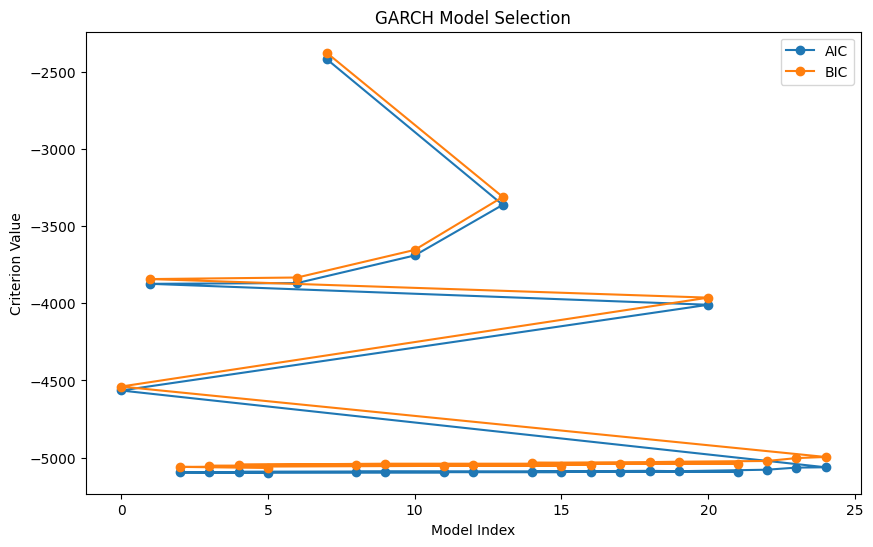

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(results_df['AIC'], label='AIC', marker='o')
plt.plot(results_df['BIC'], label='BIC', marker='o')
plt.title('GARCH Model Selection')
plt.xlabel('Model Index')
plt.ylabel('Criterion Value')
plt.legend()
plt.show()

We see that the  Model seem apropriate to model the volatility as measured by Garman-Klass Method. \

In [8]:
best_model_row = results_df.iloc[0]
best_p = best_model_row['p']
best_q = best_model_row['q']

print(f"Best GARCH Model: GARCH({best_p}, {best_q})")
best_model = fitted_models[(best_p, best_q)]

# Display summary of the best model
print(best_model.summary())

Best GARCH Model: GARCH(2.0, 1.0)
                              AR - GARCH Model Results                              
Dep. Variable:                        ropen   R-squared:                       0.000
Mean Model:                              AR   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                2555.02
Distribution:      Standardized Student's t   AIC:                          -5098.04
Method:                  Maximum Likelihood   BIC:                          -5067.23
                                              No. Observations:                 1256
Date:                      Fri, Jan 24 2025   Df Residuals:                     1255
Time:                              22:11:41   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
-----------------------------------------------

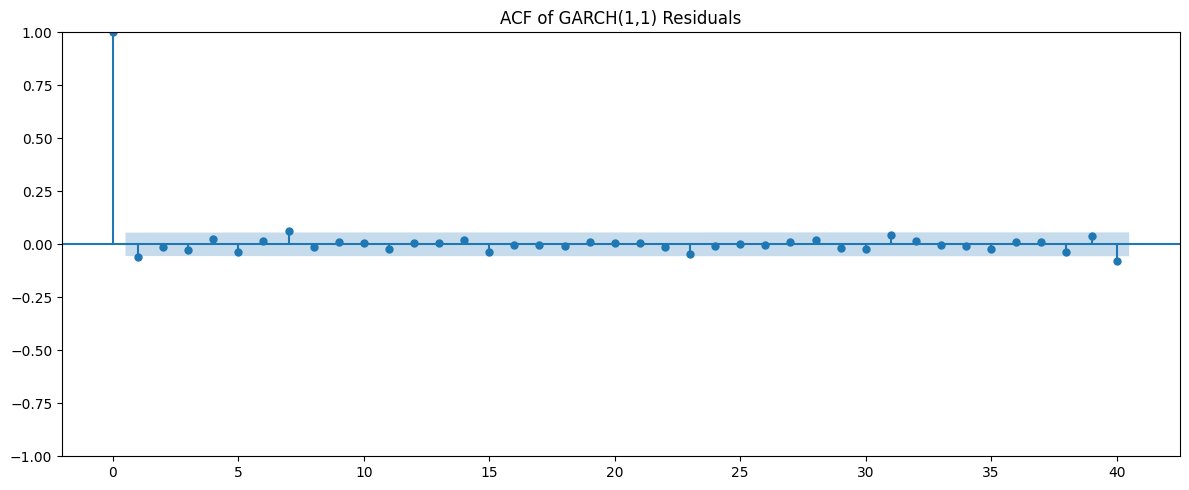

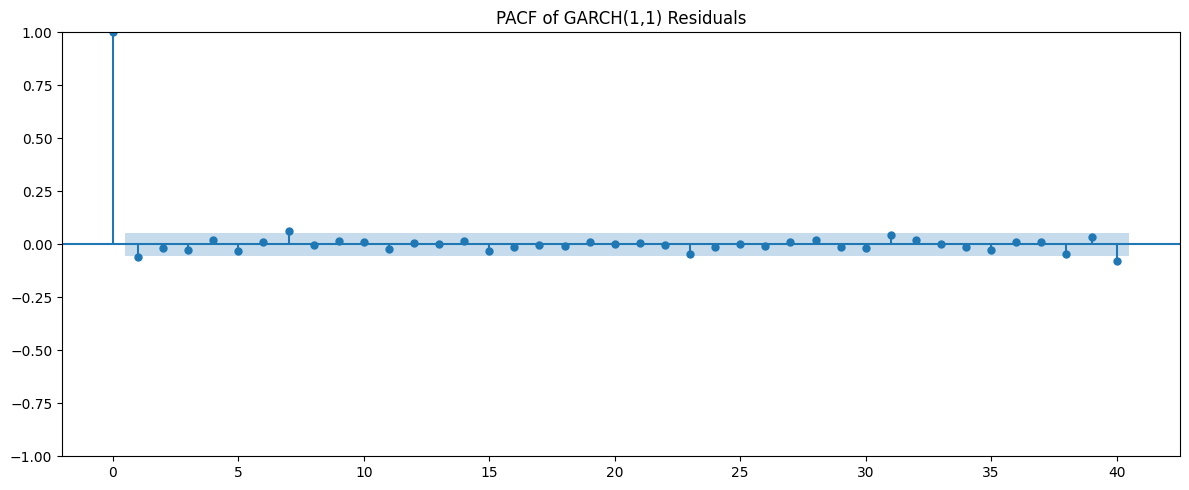

In [9]:
residuals=best_model.resid
plt.figure(figsize=(12, 5))
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF of GARCH(1,1) Residuals')
plt.tight_layout()
plt.show()

# Plot PACF
plt.figure(figsize=(12, 5))
plot_pacf(residuals, lags=40, ax=plt.gca())
plt.title('PACF of GARCH(1,1) Residuals')
plt.tight_layout()
plt.show()

We see that the PACF get below 30% immediately after the first lags and ACF show sa slowly decaying ACF after the first two indicating a possible trend


Ljung-Box Test for Residual Independence:
      lb_stat  lb_pvalue
10  13.484441   0.197833


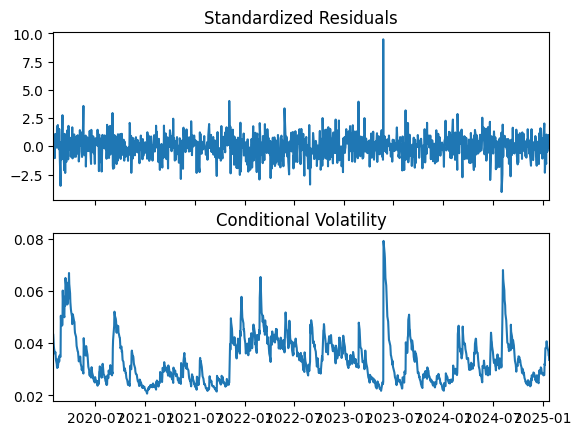

In [10]:
best_model.plot()



lb_test = acorr_ljungbox(best_model.resid, lags=[10], return_df=True)
print("Ljung-Box Test for Residual Independence:")
print(lb_test)

P-value is below the threshold rejecting the null hypothesis of the data residuals in the model being uncorelated

In [11]:

cv=best_model.conditional_volatility


In [12]:
model = MarkovRegression(data['GK_vol'], k_regimes=2, switching_variance=True)#allowing variance to switch between regimes, data['GK_vol']
results = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [13]:
print(results.summary())



                        Markov Switching Model Results                        
Dep. Variable:                 GK_vol   No. Observations:                 1256
Model:               MarkovRegression   Log Likelihood                4145.528
Date:                Fri, 24 Jan 2025   AIC                          -8279.057
Time:                        22:11:50   BIC                          -8248.243
Sample:                             0   HQIC                         -8267.475
                               - 1256                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0182      0.000     40.134      0.000       0.017       0.019
sigma2      3.109e-05   3.97e-06      7.838      0.0

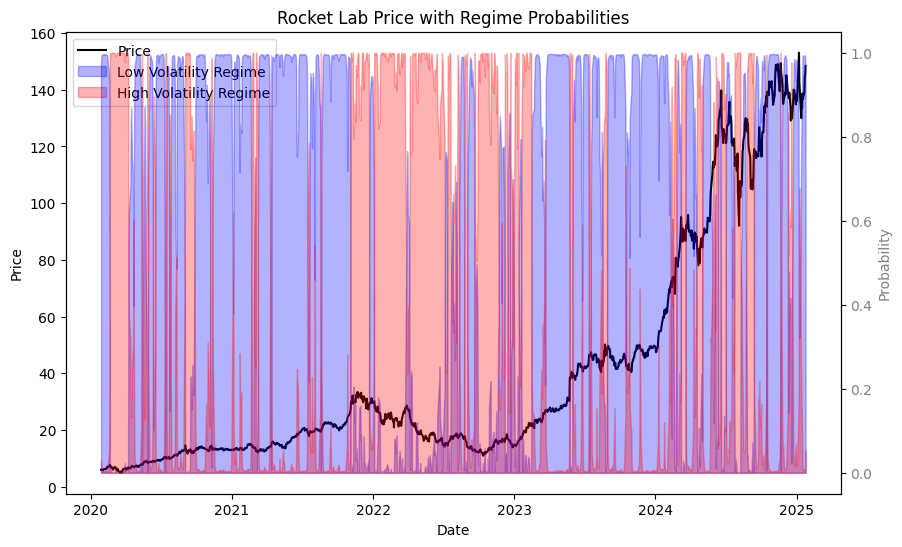

In [14]:
# Plot the smoothed probabilities of being in each regime
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the volatility on the left axis
ax.plot(data.index, data['Open'], label='Price', color='black')
ax.set_ylabel('Price', color='black')
ax.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for the probabilities
ax2 = ax.twinx()

# Plot the probabilities for low and high volatility regimes on the right axis
ax2.fill_between(data.index, 0, results.smoothed_marginal_probabilities[0], color='blue', alpha=0.3, label='Low Volatility Regime')
ax2.fill_between(data.index, 0, results.smoothed_marginal_probabilities[1], color='red', alpha=0.3, label='High Volatility Regime')
ax2.set_ylabel('Probability', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

# Set common properties
ax.set_title('Rocket Lab Price with Regime Probabilities')
ax.set_xlabel('Date')

# Combine the legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

In [15]:
#Switching places then contin



1- Anna Mikusheva, course materials for 14.384 Time Series Analysis, Fall 2007. MIT OpenCourseWare (http://ocw.mit.edu)

2- Yuan, Yuan and Mitra, Gautam, Market Regime Identification Using Hidden Markov Models (September 18, 2016). Available at SSRN: https://ssrn.com/abstract=3406068 or http://dx.doi.org/10.2139/ssrn.3406068

